# MNIST Digit Classifier from Scratch

## Input

### Dataset

- 28 × 28 grayscale digit images
- Each image contains **784 pixels**
- Pixel values range from:
  - **0** → Black
  - **255** → White

The input matrix is written as

$$
X^T = [x_1, x_2, \ldots, x_m]
$$

where \(m\) is the number of training examples.

---

## Output

There are **10 classes**, corresponding to the digits:

$$
0,1,2,3,4,5,6,7,8,9
$$

---

# Neural Network

A **2-layer neural network**.

## Layer 0

### Input Layer

- 784 nodes
- One node for each pixel

---

## Layer 1

### Hidden Layer

- 10 nodes

---

## Layer 2

### Output Layer

- 10 nodes
- Each node corresponds to one digit that can be predicted

---

# Forward Propagation

The input image is passed through the network.

Input:

$$
A^{[0]} = X
$$

### Hidden Layer

Linear transformation

$$
Z^{[1]} = W^{[1]}A^{[0]} + b^{[1]}
$$

Activation

$$
A^{[1]} = \mathrm{ReLU}(Z^{[1]})
$$

### Output Layer

Linear transformation

$$
Z^{[2]} = W^{[2]}A^{[1]} + b^{[2]}
$$

Activation

$$
A^{[2]} = \mathrm{Softmax}(Z^{[2]})
$$

Softmax outputs the probability of the image belonging to each digit class.

---

# Backpropagation

## Output Layer

$$
dZ^{[2]} = A^{[2]} - Y
$$

$$
dW^{[2]} = \frac{1}{m}dZ^{[2]}A^{[1]T}
$$

$$
db^{[2]} = \frac{1}{m}\sum dZ^{[2]}
$$

---

## Hidden Layer

$$
dZ^{[1]} = W^{[2]T}dZ^{[2]}
$$

$$
dW^{[1]} = \frac{1}{m}dZ^{[1]}X^T
$$

$$
db^{[1]} = \frac{1}{m}\sum dZ^{[1]}
$$

---

# Optimization

Update the parameters using gradient descent.

$$
W^{[1]} = W^{[1]} - \alpha dW^{[1]}
$$

$$
b^{[1]} = b^{[1]} - \alpha db^{[1]}
$$

$$
W^{[2]} = W^{[2]} - \alpha dW^{[2]}
$$

$$
b^{[2]} = b^{[2]} - \alpha db^{[2]}
$$

where

$$
\alpha
$$

is the learning rate.

DATA

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# Load the CSV file into a Pandas DataFrame.
# The dataset is stored in the variable 'data'.

data = pd.read_csv('data/train.csv')

# Display the first 5 rows of the dataset.

data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


SPLIT

In [20]:
# Convert the Pandas DataFrame into a NumPy array.
data = np.array(data)

# Get the dimensions (shape) of the dataset.
m,n = data.shape
print(m,n)

42000 785


In [21]:
# Shuffle the rows of the dataset randomly.
np.random.shuffle(data)

# Select the first 1000 examples for validation.
#Transpose makes each column represent one training example
data_val = data[0:1000].T

# The first row contains the labels (digits 0-9).
Y_val = data_val[0]

# The remaining 784 rows contain the pixel values.
X_val = data_val[1:n] / 255

# Extract the training labels
data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n] / 255

In [ ]:
#He initialization
def init_params():
    # Initialize the weights connecting the input layer (784 pixels) to the hidden layer (10 neurons).
    W1 = np.random.randn(10,784)  * np.sqrt(2 / 784)   
    # Initialize the biases for the 10 hidden neurons.
    b1 = np.random.randn(10, 1)
    # Initialize the weights connecting the hidden layer (10 neurons) to the output layer (10 neurons/classes: digits 0-9).
    W2 = np.random.randn(10, 10) * np.sqrt(2 / 10) 
    # Initialize the biases for the output layer.
    b2 = np.random.randn(10, 1)
    return W1, b1, W2, b2

In [41]:
# Apply the ReLU (Rectified Linear Unit) activation function.
def ReLU(Z):
    return np.maximum(0,Z)

In [42]:
# Apply the Softmax activation function to the output layer.
def softmax(Z):
    exp = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return exp / np.sum(exp, axis=0, keepdims=True)

In [43]:
def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

In [44]:
def forward_prop(W1, b1, W2, b2, X):
    # Compute the weighted sum for the hidden layer.
    Z1 = W1.dot(X) + b1
    # Apply the ReLU activation function.
    A1 = ReLU(Z1)
    # Compute the weighted sum for the output layer.
    Z2 = W2.dot(A1) + b2
    # Apply the Softmax activation function to convert the output scores into probabilities for each class.
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2
    

In [45]:
def ReLU_deriv(Z):
    return Z > 0

In [46]:
def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    m = X.shape[1]
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2, axis=1, keepdims=True)
    dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1, axis=1, keepdims=True)
    return dW1, db1, dW2, db2

In [47]:
def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2

In [48]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size


In [49]:
def gradient_descent(X,Y, iterations, alpha):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 10 == 0:
            print("Iteration:", i)
            print("Accuracy:", get_accuracy(get_predictions(A2), Y))
    return W1, b1,W2, b2

        

In [50]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 500, 0.10)

Iteration: 0
[7 7 7 ... 7 7 7] [8 7 1 ... 9 2 1]
Accuracy: 0.12948780487804878
Iteration: 10
[8 7 1 ... 7 2 7] [8 7 1 ... 9 2 1]
Accuracy: 0.3277317073170732
Iteration: 20
[8 7 1 ... 7 2 1] [8 7 1 ... 9 2 1]
Accuracy: 0.4642926829268293
Iteration: 30
[8 7 1 ... 7 2 1] [8 7 1 ... 9 2 1]
Accuracy: 0.48653658536585365
Iteration: 40
[8 7 1 ... 7 2 1] [8 7 1 ... 9 2 1]
Accuracy: 0.5184146341463415
Iteration: 50
[8 7 1 ... 7 2 1] [8 7 1 ... 9 2 1]
Accuracy: 0.5800975609756097
Iteration: 60
[8 7 1 ... 7 2 1] [8 7 1 ... 9 2 1]
Accuracy: 0.6332926829268293
Iteration: 70
[8 7 1 ... 7 2 1] [8 7 1 ... 9 2 1]
Accuracy: 0.6653902439024391
Iteration: 80
[8 7 1 ... 7 2 1] [8 7 1 ... 9 2 1]
Accuracy: 0.691170731707317
Iteration: 90
[8 7 1 ... 7 2 1] [8 7 1 ... 9 2 1]
Accuracy: 0.7104878048780487
Iteration: 100
[8 7 1 ... 7 2 1] [8 7 1 ... 9 2 1]
Accuracy: 0.7264878048780488
Iteration: 110
[8 7 1 ... 7 2 1] [8 7 1 ... 9 2 1]
Accuracy: 0.7409268292682927
Iteration: 120
[8 7 1 ... 7 2 1] [8 7 1 ... 9 2 1]

In [51]:
def make_predictions(X, W1, b1, W2, b2):
    _,_,_,A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

In [52]:
def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  [6]
Label:  6


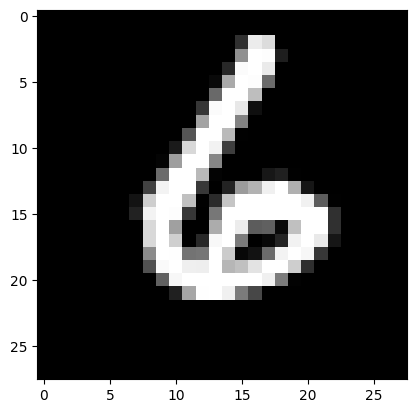

Prediction:  [1]
Label:  1


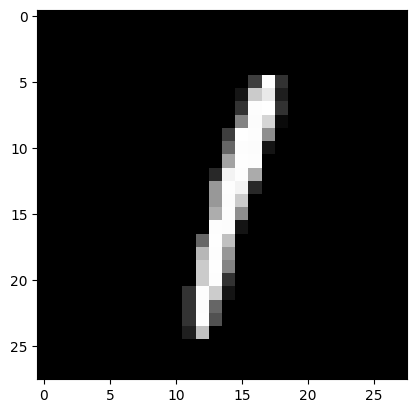

Prediction:  [9]
Label:  9


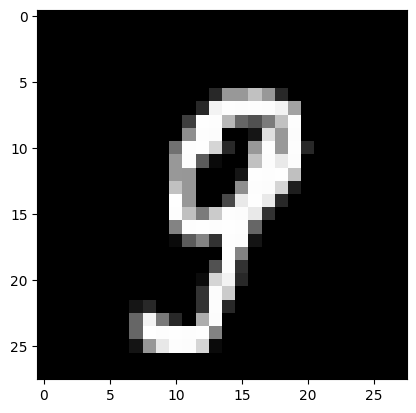

Prediction:  [5]
Label:  5


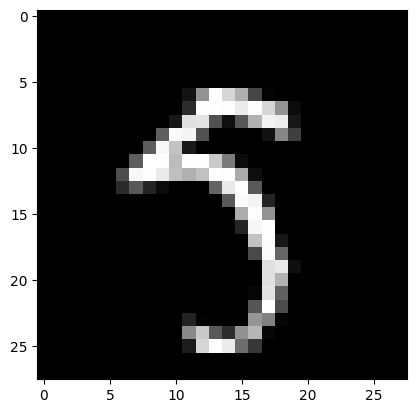

In [ ]:
test_prediction(11, W1, b1, W2, b2)
test_prediction(12, W1, b1, W2, b2)
test_prediction(22, W1, b1, W2, b2)
test_prediction(10, W1, b1, W2, b2)